Antes de decidir qué analizar, hay que ver qué hay. Este cuaderno se va llenando de a un paso por vez.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RUTA = "../data/raw/"

ventas = pd.read_csv(RUTA + "train.csv", parse_dates=["date"])

print(f"{len(ventas):,} filas y {ventas.shape[1]} columnas")
print(f"Del {ventas.date.min():%d/%m/%Y} al {ventas.date.max():%d/%m/%Y}")

3,000,888 filas y 6 columnas
Del 01/01/2013 al 15/08/2017


## 1. Los primeros 30 registros

Una fila es la venta de una familia de producto, en una tienda, en un día.

In [2]:
ventas.head(30)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


## 2. Qué productos existen

El dataset no tiene productos individuales: los agrupa en **familias**.

In [3]:
familias = ventas.family.unique()

print(len(familias), "familias de producto:")
for f in sorted(familias):
    print(" -", f)

33 familias de producto:
 - AUTOMOTIVE
 - BABY CARE
 - BEAUTY
 - BEVERAGES
 - BOOKS
 - BREAD/BAKERY
 - CELEBRATION
 - CLEANING
 - DAIRY
 - DELI
 - EGGS
 - FROZEN FOODS
 - GROCERY I
 - GROCERY II
 - HARDWARE
 - HOME AND KITCHEN I
 - HOME AND KITCHEN II
 - HOME APPLIANCES
 - HOME CARE
 - LADIESWEAR
 - LAWN AND GARDEN
 - LINGERIE
 - LIQUOR,WINE,BEER
 - MAGAZINES
 - MEATS
 - PERSONAL CARE
 - PET SUPPLIES
 - PLAYERS AND ELECTRONICS
 - POULTRY
 - PREPARED FOODS
 - PRODUCE
 - SCHOOL AND OFFICE SUPPLIES
 - SEAFOOD


## 3. Las ventas a lo largo del tiempo

Suma de las ventas de todas las tiendas y familias, día a día.

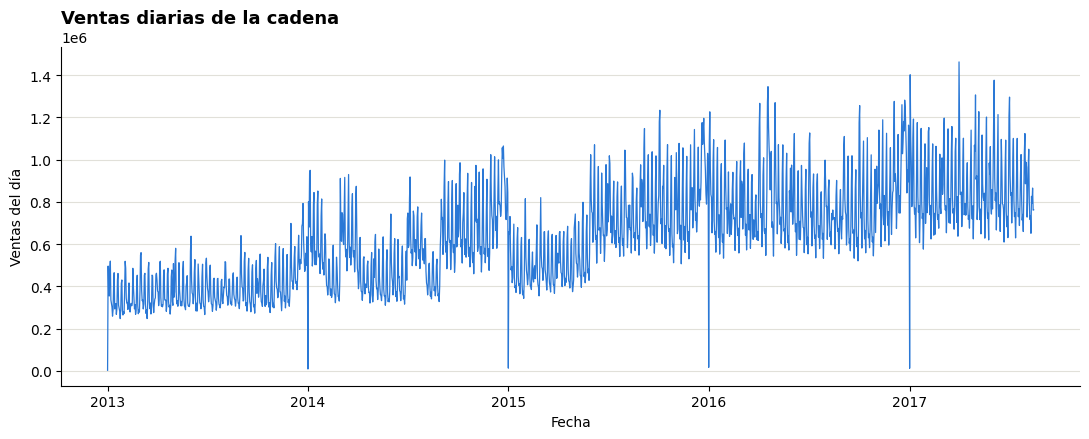

In [4]:
por_fecha = ventas.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(por_fecha.index, por_fecha.values, linewidth=0.9, color="#2a78d6")

ax.set_title("Ventas diarias de la cadena", loc="left", fontsize=13, fontweight="600")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas del día")
ax.grid(axis="y", color="#e1e0d9")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 4. De dónde vienen los ceros

El 31 % de las filas tiene `sales = 0`, pero no todas significan lo mismo, y la
diferencia decide qué se puede borrar:

- **La tienda todavía no existía.** Ocho tiendas abren después de enero de 2013 y
  arrastran filas en cero desde el principio del panel. Eso sí es ruido: la tienda
  no vendió nada porque no estaba.
- **La tienda no maneja esa familia.** Un local pequeño sin sección de librería
  reporta cero en `BOOKS` todos los días. El cero es real y además es informativo.
- **Nadie compró ese día.** En familias de baja rotación es lo normal, y borrarlo
  sesgaría al alza cualquier promedio.

In [5]:
n = len(ventas)

# Primer dia con venta de cada tienda: antes de eso, la tienda no existia.
apertura = ventas[ventas.sales > 0].groupby("store_nbr").date.min()
no_abierta = ventas.date < ventas.store_nbr.map(apertura)

vivas = ventas[~no_abierta]

# Combinaciones tienda-familia que jamas vendieron una unidad: no hay surtido.
maximo = vivas.groupby(["store_nbr", "family"]).sales.max()
sin_surtido = maximo[maximo == 0].index

print(f"sales = 0           {(ventas.sales == 0).mean():6.1%} de las filas")
print(f"  tienda sin abrir  {no_abierta.mean():6.1%}  ({no_abierta.sum():,} filas, 8 tiendas)")
print(f"  resto             {(vivas.sales == 0).mean():6.1%}  de las filas vivas")
print()
print(f"tienda-familia que nunca vendieron nada: {len(sin_surtido)} de {len(maximo)}")
print()
print("Familias con más ceros (% de días sin ninguna venta):")
pct = vivas.groupby("family").sales.apply(lambda s: 100 * (s == 0).mean())
print(pct.sort_values(ascending=False).head(6).round(1).to_string())

sales = 0            31.3% de las filas
  tienda sin abrir    7.4%  (222,057 filas, 8 tiendas)
  resto              25.8%  de las filas vivas

tienda-familia que nunca vendieron nada: 53 de 1782

Familias con más ceros (% de días sin ninguna venta):


family
BOOKS                         96.7
BABY CARE                     93.7
SCHOOL AND OFFICE SUPPLIES    72.0
HOME APPLIANCES               71.4
LADIESWEAR                    56.6
MAGAZINES                     53.1


### Y las fechas

Antes de limpiar conviene mirar el calendario: hay días que directamente no están.

In [6]:
por_dia = ventas.groupby("date").sales.sum()
completo = pd.date_range(por_dia.index.min(), por_dia.index.max(), freq="D")

print("Fechas ausentes del dataset:")
for d in completo.difference(por_dia.index):
    print(f"  {d:%d/%m/%Y}")

print()
print("Los cinco días de menor venta:")
print(por_dia.nsmallest(5).round(0).to_string())

Fechas ausentes del dataset:
  25/12/2013
  25/12/2014
  25/12/2015
  25/12/2016

Los cinco días de menor venta:
date
2013-01-01     2512.0
2014-01-01     8602.0
2017-01-01    12083.0
2015-01-01    12774.0
2016-01-01    16433.0


Los **25 de diciembre no existen** en los datos: la cadena cierra y no se
reporta nada. Y los días más flojos son los **1 de enero**, con ventas reales pero
mínimas (2.512 el 1/1/2013 contra unas 400.000 de un día cualquiera).

Ninguno de los dos es un error que haya que corregir, pero los dos rompen cualquier
media móvil o comparación día contra día, así que conviene tenerlos anotados.

## 5. La limpieza

Dos exclusiones, las dos justificadas por lo anterior. Los ceros de baja rotación se
quedan: son el comportamiento real del negocio.

In [7]:
limpias = ventas[~no_abierta].copy()

clave = pd.MultiIndex.from_arrays([limpias.store_nbr, limpias.family])
limpias = limpias[~clave.isin(sin_surtido)]

print(f"Filas originales  {n:,}")
print(f"  - tienda sin abrir      -{no_abierta.sum():,}")
print(f"  - sin surtido           -{len(ventas) - no_abierta.sum() - len(limpias):,}")
print(f"Filas limpias     {len(limpias):,}  ({len(limpias)/n:.1%} de las originales)")
print()
print(f"sales = 0 ahora: {(limpias.sales == 0).mean():.1%}  (antes {(ventas.sales == 0).mean():.1%})")

Filas originales  3,000,888
  - tienda sin abrir      -222,057
  - sin surtido           -81,624
Filas limpias     2,697,207  (89.9% de las originales)

sales = 0 ahora: 23.6%  (antes 31.3%)


## 6. Las ventas por familia

Con 33 familias en un mismo gráfico no se lee nada, así que van las **seis más
grandes** y el resto agrupado. Dos decisiones más: la serie es **mensual** —la diaria
es puro diente de sierra— y se corta en **julio de 2017**, porque agosto está
incompleto (el dataset termina el día 15) y aparecería como un derrumbe que no
existe.

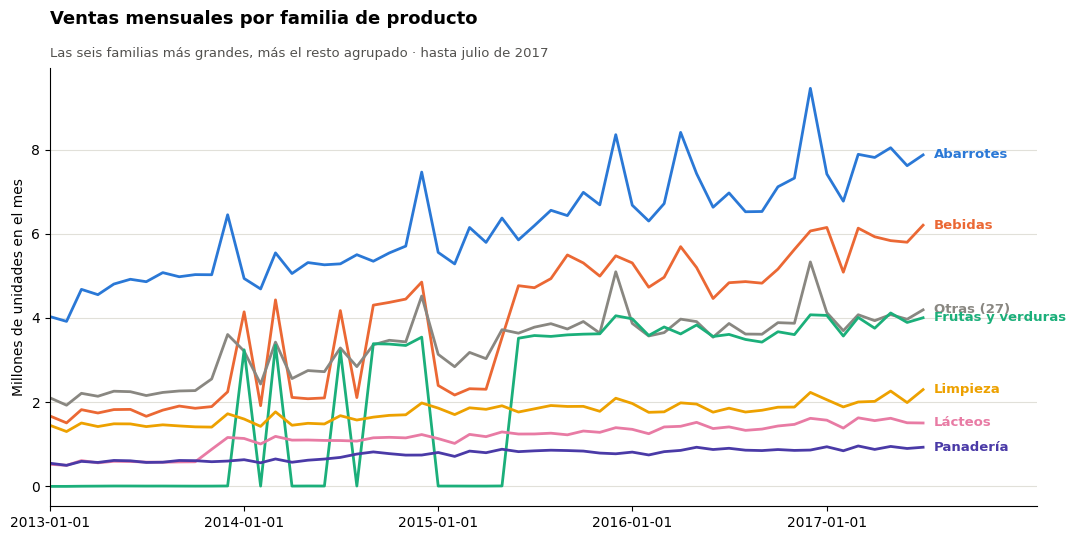

In [8]:
NOMBRES = {"GROCERY I": "Abarrotes", "BEVERAGES": "Bebidas",
           "PRODUCE": "Frutas y verduras", "CLEANING": "Limpieza",
           "DAIRY": "Lácteos", "BREAD/BAKERY": "Panadería", "OTRAS": "Otras (27)"}

COLORES = {"Abarrotes": "#2a78d6", "Bebidas": "#eb6834", "Frutas y verduras": "#1baf7a",
           "Limpieza": "#eda100", "Lácteos": "#e87ba4", "Panadería": "#4a3aa7",
           "Otras (27)": "#898781"}

completos = limpias[limpias.date < "2017-08-01"]
top6 = completos.groupby("family").sales.sum().nlargest(6).index

mensual = completos.assign(
    grupo=completos.family.where(completos.family.isin(top6), "OTRAS").map(NOMBRES)
).groupby([pd.Grouper(key="date", freq="MS"), "grupo"]).sales.sum().unstack() / 1e6

orden = mensual.iloc[-1].sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 5.5))

for familia in orden:
    ax.plot(mensual.index, mensual[familia], color=COLORES[familia], linewidth=2)
    # Etiqueta al final de cada linea: mas legible que una leyenda de siete series.
    ax.text(mensual.index[-1] + pd.Timedelta(days=20), mensual[familia].iloc[-1],
            familia, color=COLORES[familia], fontsize=9.5, va="center", fontweight="600")

ax.set_title("Ventas mensuales por familia de producto", loc="left",
             fontsize=13, fontweight="600", pad=32)
ax.text(0, 1.02, "Las seis familias más grandes, más el resto agrupado · hasta julio de 2017",
        transform=ax.transAxes, fontsize=9.5, color="#52514e", va="bottom")
ax.set_ylabel("Millones de unidades en el mes")
ax.set_xlim(mensual.index[0], mensual.index[-1] + pd.Timedelta(days=215))
ax.set_xticks(pd.date_range("2013-01-01", "2017-01-01", freq="YS"))
ax.grid(axis="y", color="#e1e0d9")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

El gráfico deja ver lo esperable —abarrotes y bebidas dominan, todo crece— y
una cosa que no cuadra: **la línea de frutas y verduras se desploma al piso durante
meses enteros** entre 2013 y 2015, y después se normaliza. Una cadena de
supermercados no deja de vender verduras medio año.

## 7. El problema de frutas y verduras

Los meses malos no son ceros: son valores unas 450 veces más chicos, que en una
escala de millones se ven pegados al eje. La pista está en los decimales.

In [9]:
con_venta = limpias[limpias.sales > 0].copy()
con_venta["decimal"] = con_venta.sales % 1 != 0

produce = con_venta[con_venta.family == "PRODUCE"]
por_mes = produce.groupby(pd.Grouper(key="date", freq="MS")).agg(
    total=("sales", "sum"),
    pct_decimales=("decimal", "mean"),
    venta_media=("sales", "mean"))
por_mes["pct_decimales"] *= 100

print("Frutas y verduras, mes a mes (primeros 18 meses de 2014 en adelante):")
print(por_mes.loc["2014-01":"2015-06"].round(1).to_string())

Frutas y verduras, mes a mes (primeros 18 meses de 2014 en adelante):
                total  pct_decimales  venta_media
date                                             
2014-01-01  3243616.6          100.0       2297.2
2014-02-01     6576.0            0.0         10.9
2014-03-01  3352346.3           99.9       2300.9
2014-04-01     7152.0            0.0         11.4
2014-05-01     9094.0            0.0         14.0
2014-06-01     8283.0            0.0         13.2
2014-07-01  3216023.3           99.9       2195.2
2014-08-01     8265.0            0.0         11.6
2014-09-01  3388714.6           99.8       2369.7
2014-10-01  3380437.0           99.9       2271.8
2014-11-01  3346861.6           99.9       2324.2
2014-12-01  3545158.5          100.0       2461.9
2015-01-01     7554.0            0.0         11.4
2015-02-01     7907.0            0.0         12.7
2015-03-01     6905.0            0.0         10.3
2015-04-01     7163.0            0.0         10.8
2015-05-01    10172.0         

El patrón es inequívoco: los meses con totales grandes tienen **casi 100 % de
valores con decimales** y una venta media de miles; los meses chicos tienen **0 % de
decimales** y una media de once. Lo que cambia no es la demanda, es **la unidad de
medida**: unos meses se registra el peso en kilos y otros el conteo de piezas.

Y cambia en todas las tiendas a la vez, lo que descarta que sea un problema de
locales sueltos.

In [10]:
kilos = produce.groupby(pd.Grouper(key="date", freq="MS")).decimal.mean() > 0.9
tiendas_altas = (produce[produce.sales > 100]
                 .groupby(pd.Grouper(key="date", freq="MS")).store_nbr.nunique())

print(f"Meses registrados en kilos:    {kilos.sum()} de {len(kilos)}")
print(f"Meses registrados en unidades: {(~kilos).sum()}")
print()
print("Tiendas que reportan ventas grandes, en un mes de cada tipo:")
print(f"  2014-01 (kilos):    {tiendas_altas.get('2014-01-01', 0)} tiendas")
print(f"  2014-02 (unidades): {tiendas_altas.get('2014-02-01', 0)} tiendas")

Meses registrados en kilos:    34 de 54
Meses registrados en unidades: 20

Tiendas que reportan ventas grandes, en un mes de cada tipo:
  2014-01 (kilos):    47 tiendas
  2014-02 (unidades): 0 tiendas


### Qué familias afecta

Que un producto se venda por peso no es un problema: carnes y aves se registran
siempre así. El problema es **cambiar de criterio en el tiempo**, y eso solo le pasa
a frutas y verduras.

In [11]:
pct = con_venta.groupby("family").decimal.mean().mul(100)
pct = pct[pct > 0.5].sort_values(ascending=False)

resumen = pd.DataFrame({"pct_decimales": pct.round(1)})
resumen["criterio"] = ["siempre por peso" if p > 99 else "mezcla estable"
                       for p in pct]

# Una familia es inestable si tiene meses casi todos por peso y meses casi ninguno.
for familia in pct.index:
    pm = con_venta[con_venta.family == familia].groupby(
        pd.Grouper(key="date", freq="MS")).decimal.mean()
    if (pm > 0.9).any() and (pm < 0.1).any():
        resumen.loc[familia, "criterio"] = "ALTERNA entre kilos y unidades"

print(resumen.to_string())

                pct_decimales                        criterio
family                                                       
MEATS                    99.9                siempre por peso
POULTRY                  99.9                siempre por peso
PRODUCE                  80.3  ALTERNA entre kilos y unidades
DELI                     69.4                  mezcla estable
PREPARED FOODS           57.6                  mezcla estable
SEAFOOD                  55.9                  mezcla estable
FROZEN FOODS             50.7                  mezcla estable
BREAD/BAKERY             47.2                  mezcla estable
GROCERY I                16.5                  mezcla estable


**Consecuencia práctica:** cualquier suma que incluya frutas y verduras está
mezclando kilos con piezas, así que su volumen, su crecimiento y su participación en
el portafolio no son comparables ni consigo mismos en el tiempo. Hay tres salidas
posibles y conviene elegir a conciencia antes de seguir:

1. **Excluir la familia** de los análisis de volumen. Es lo más limpio y cuesta alrededor
   del 11 % del volumen registrado (porcentaje que, él mismo, está contaminado
   por la mezcla de unidades).
2. **Quedarse solo con los meses en kilos** (34 de 54), y aceptar una serie con
   huecos que complica cualquier comparación interanual.
3. **Convertir las piezas a kilos** con un factor estimado de la razón entre
   períodos. Es lo que conserva más datos y lo más frágil: el factor sería un
   supuesto sin manera de verificarlo.

Queda pendiente decidir cuál.